# QuantumCafe-CR -- Exploratory Data Analysis
**Datasets:** BRACOL, JMuBEN, JMuBEN2  |  **Classes:** healthy, rust, cercospora, miner, phoma

In [1]:
import sys
sys.path.insert(0, '..')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from src.data.label_mapper import UNIFIED_LABELS, normalize

RAW = Path('../data/raw')
DATASETS = {'BRACOL': RAW/'bracol', 'JMuBEN': RAW/'jmuben', 'JMuBEN2': RAW/'jmuben2'}
COLORS = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6']
CLASS_COLORS = dict(zip(UNIFIED_LABELS, COLORS))
IMG_EXT = {'.jpg','.jpeg','.png','.bmp'}
print('Setup OK')


Setup OK


## 1. Dataset Overview

In [2]:
def scan_dataset(root):
    records = []
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir(): continue
        try: unified = normalize(class_dir.name)
        except ValueError: continue
        for img in class_dir.glob('**/*'):
            if img.suffix.lower() in IMG_EXT:
                records.append({'dataset':root.name,'label':unified,
                                 'path':str(img),'bytes':img.stat().st_size})
    return records

all_records = []
for name, root in DATASETS.items():
    if root.exists():
        recs = scan_dataset(root)
        all_records.extend(recs)
        mb = sum(r['bytes'] for r in recs) / 1e6
        print(f'{name}: {len(recs):,} images | {mb:.1f} MB')
    else:
        print(f'{name}: NOT FOUND -- run scripts/unify_datasets.py')
df = pd.DataFrame(all_records)
print(f'Total: {len(df):,} images | {df.bytes.sum()/1e9:.2f} GB')


BRACOL: 0 images | 0.0 MB
JMuBEN: 22,588 images | 547.1 MB
JMuBEN2: 35,962 images | 1292.0 MB
Total: 58,550 images | 1.84 GB


## 2. Class Distribution per Dataset

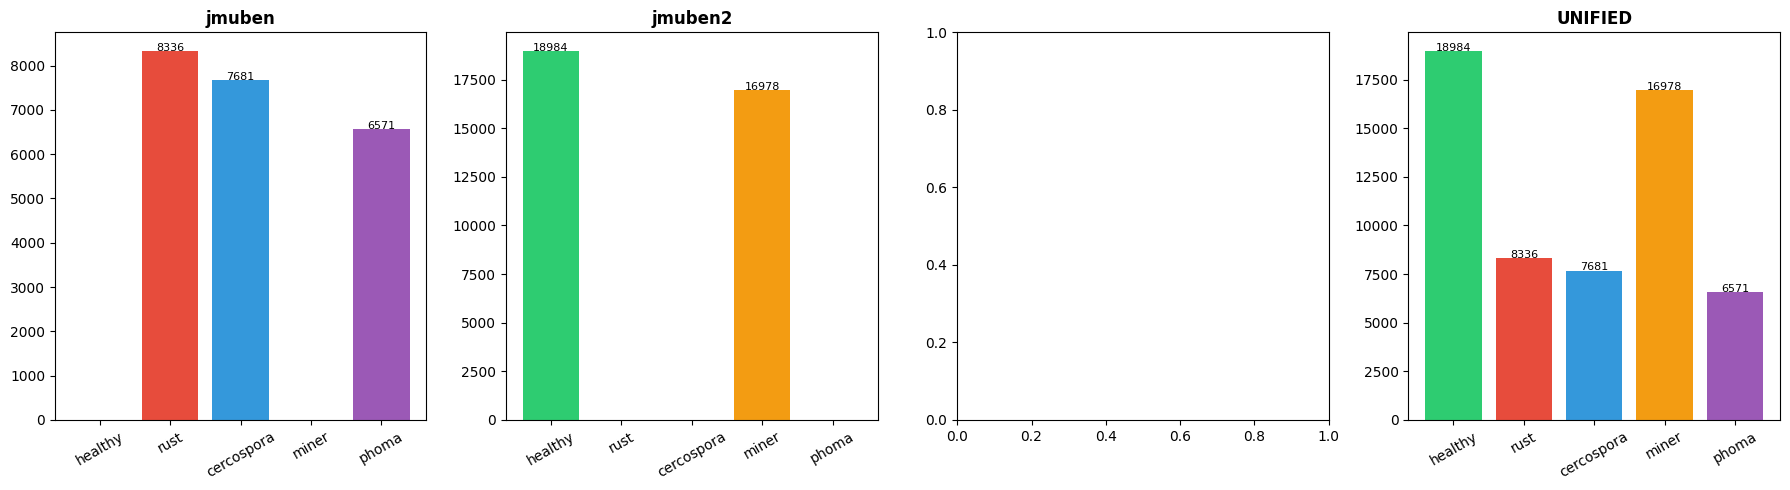

label
healthy       18984
rust           8336
cercospora     7681
miner         16978
phoma          6571


In [3]:
pivot = df.groupby(['dataset','label']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=UNIFIED_LABELS, fill_value=0)
unified_counts = df.groupby('label').size().reindex(UNIFIED_LABELS, fill_value=0)

fig, axes = plt.subplots(1, len(DATASETS)+1, figsize=(18,5))
for ax, (ds, row) in zip(axes, pivot.iterrows()):
    bars = ax.bar(row.index, row.values, color=COLORS)
    ax.set_title(ds, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    [ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, str(v), ha='center', fontsize=8)
     for b,v in zip(bars,row.values) if v>0]
bars = axes[-1].bar(unified_counts.index, unified_counts.values, color=COLORS)
axes[-1].set_title('UNIFIED', fontweight='bold')
axes[-1].tick_params(axis='x', rotation=30)
[axes[-1].text(b.get_x()+b.get_width()/2, b.get_height()+10, str(v), ha='center', fontsize=8)
 for b,v in zip(bars, unified_counts.values)]
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(unified_counts.to_string())


## 3. Imbalance Analysis

In [4]:
counts = unified_counts.values.astype(float)
probs = counts / counts.sum()
shannon = -np.sum(probs * np.log2(probs + 1e-12))
balance_score = shannon / np.log2(len(UNIFIED_LABELS))
imbalance_ratio = counts.max() / counts.min()
print(f'Balance score (entropy): {balance_score:.3f}  (1.0=perfect)')
print(f'Imbalance ratio max/min: {imbalance_ratio:.1f}x')
for lbl, p in zip(UNIFIED_LABELS, probs):
    bar = '#' * int(p * 50)
    print(f'  {lbl:12s} {p*100:5.1f}%  {bar}')
if imbalance_ratio > 3:
    print('WARNING: significant imbalance -- use weighted loss or oversampling')


Balance score (entropy): 0.940  (1.0=perfect)
Imbalance ratio max/min: 2.9x
  healthy       32.4%  ################
  rust          14.2%  #######
  cercospora    13.1%  ######
  miner         29.0%  ##############
  phoma         11.2%  #####


## 4. Image Dimensions & Aspect Ratios

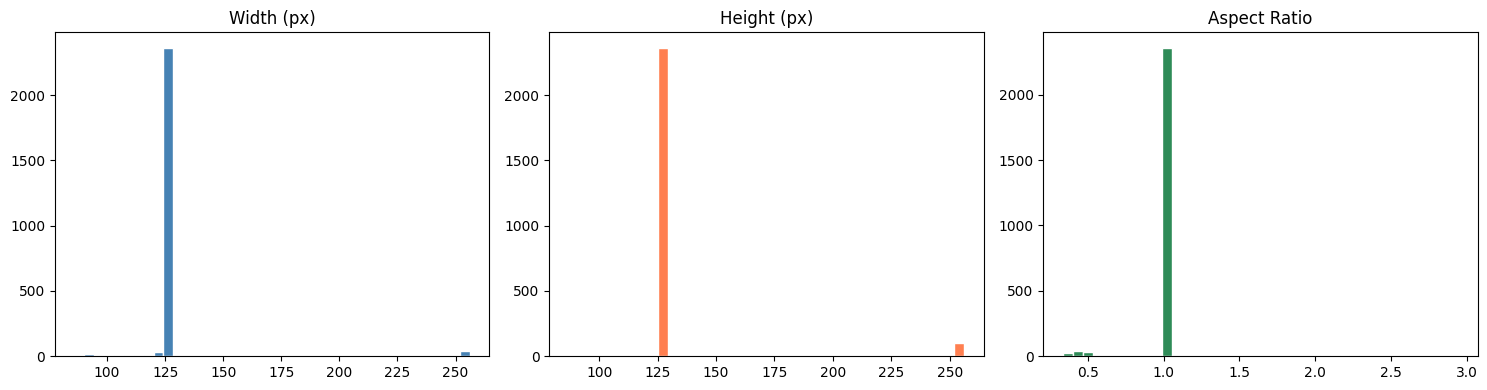

Width  mean=129  median=128  range=86-256
Height mean=133  median=128  range=87-256
Aspect mean=1.00  std=0.21


In [5]:
sample_df = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(500, len(x)), random_state=42))
widths, heights, aspects = [], [], []
for _, row in sample_df.iterrows():
    try:
        w, h = Image.open(row['path']).size
        widths.append(w); heights.append(h); aspects.append(w/h)
    except: pass

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].hist(widths, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Width (px)')
axes[1].hist(heights, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Height (px)')
axes[2].hist(aspects, bins=40, color='seagreen', edgecolor='white')
axes[2].set_title('Aspect Ratio')
plt.tight_layout()
plt.savefig('../results/figures/image_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Width  mean={np.mean(widths):.0f}  median={np.median(widths):.0f}  range={min(widths)}-{max(widths)}')
print(f'Height mean={np.mean(heights):.0f}  median={np.median(heights):.0f}  range={min(heights)}-{max(heights)}')
print(f'Aspect mean={np.mean(aspects):.2f}  std={np.std(aspects):.2f}')


## 5. Color Analysis (RGB per Class)

C:\Users\OEM\AppData\Local\Temp\ipykernel_22608\54830512.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


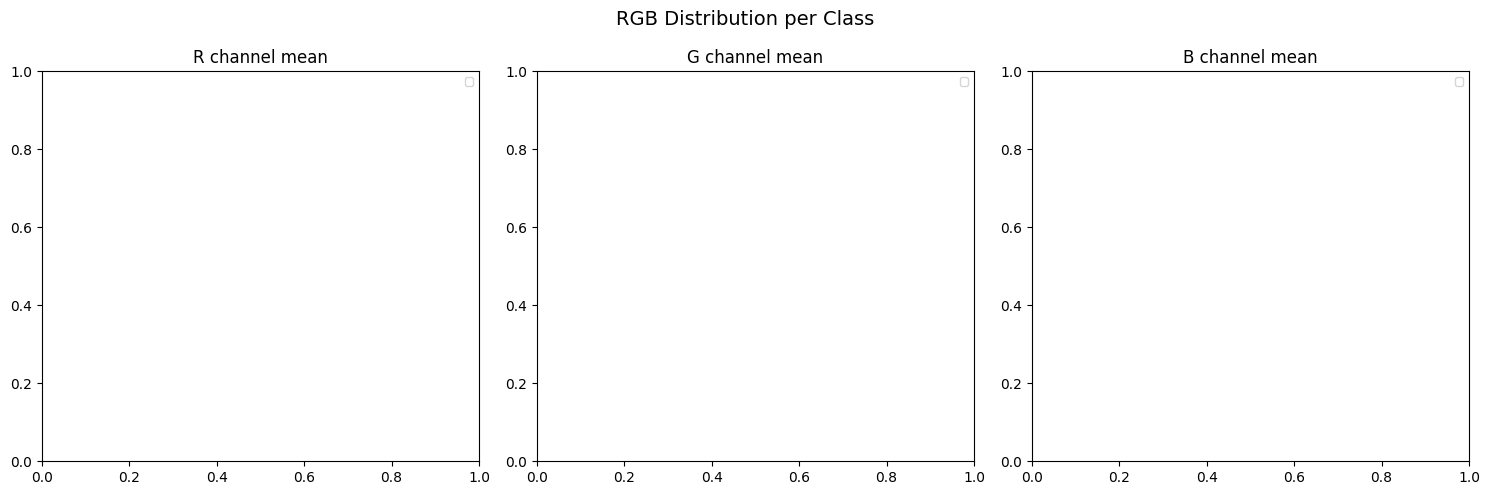

  healthy       R=nan  G=nan  B=nan
  rust          R=nan  G=nan  B=nan
  cercospora    R=nan  G=nan  B=nan
  miner         R=nan  G=nan  B=nan
  phoma         R=nan  G=nan  B=nan


c:\Users\OEM\Desktop\Proyectos\Proyectos personales\quantumcafe_cr\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\OEM\Desktop\Proyectos\Proyectos personales\quantumcafe_cr\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [6]:
color_stats = {lbl: {'r':[],'g':[],'b':[]} for lbl in UNIFIED_LABELS}
for _, row in sample_df.iterrows():
    try:
        arr = np.array(Image.open(row['path']).convert('RGB').resize((128,128))).astype(float)
        color_stats[row['label']]['r'].append(arr[:,:,0].mean())
        color_stats[row['label']]['g'].append(arr[:,:,1].mean())
        color_stats[row['label']]['b'].append(arr[:,:,2].mean())
    except: pass

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, ch in zip(axes, ['r','g','b']):
    for lbl in UNIFIED_LABELS:
        vals = color_stats[lbl][ch]
        if vals: ax.hist(vals, bins=30, alpha=0.6, label=lbl, color=CLASS_COLORS[lbl])
    ax.set_title(ch.upper() + ' channel mean')
    ax.legend(fontsize=8)
plt.suptitle('RGB Distribution per Class', fontsize=14)
plt.tight_layout()
plt.savefig('../results/figures/rgb_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
for lbl in UNIFIED_LABELS:
    r = np.mean(color_stats[lbl]['r'])
    g = np.mean(color_stats[lbl]['g'])
    b = np.mean(color_stats[lbl]['b'])
    print(f'  {lbl:12s}  R={r:.1f}  G={g:.1f}  B={b:.1f}')


## 6. Sample Images per Class

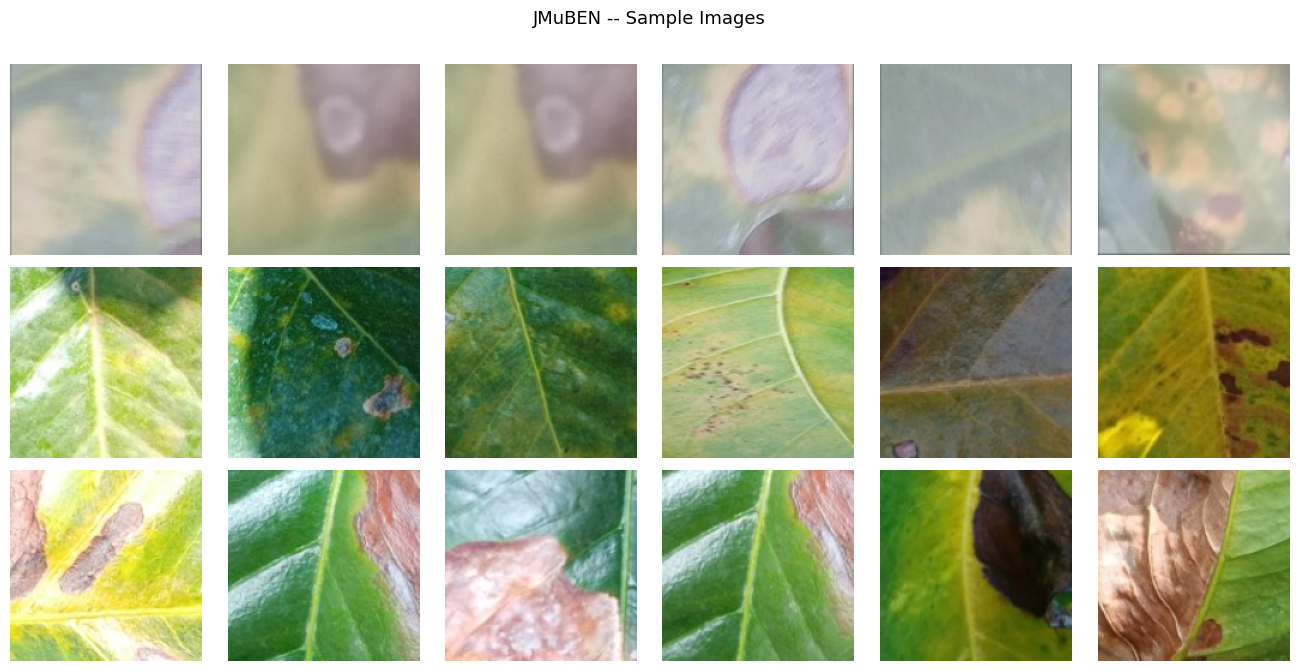

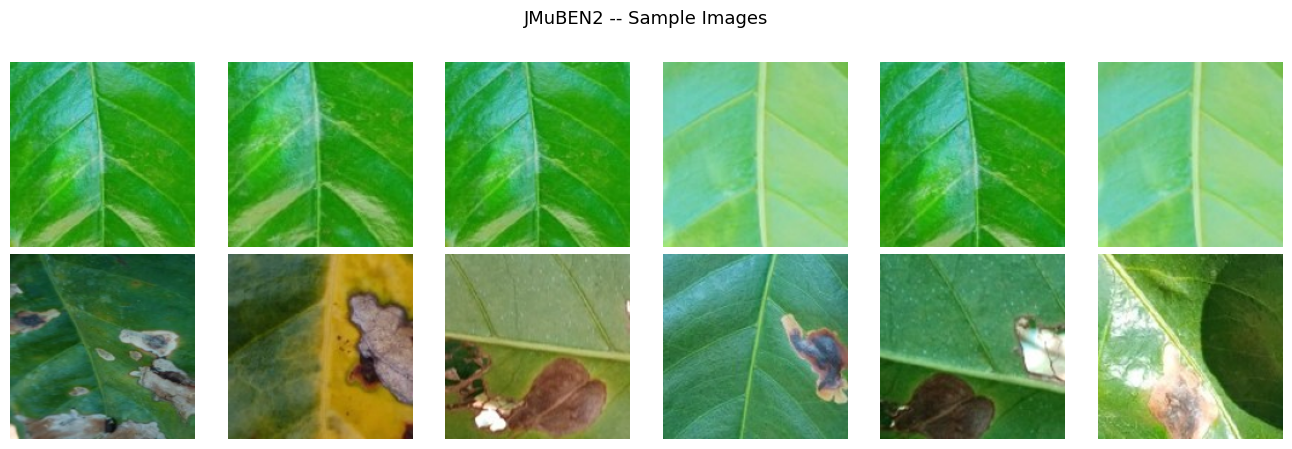

In [7]:
N = 6
for ds_name, ds_root in DATASETS.items():
    ds_df = df[df['dataset']==ds_root.name]
    if ds_df.empty: continue
    present = [l for l in UNIFIED_LABELS if l in ds_df['label'].values]
    fig, axes = plt.subplots(len(present), N, figsize=(N*2.2, len(present)*2.2))
    if len(present) == 1: axes = [axes]
    for ri, lbl in enumerate(present):
        subs = ds_df[ds_df['label']==lbl].sample(
            min(N, (ds_df['label']==lbl).sum()), random_state=42)
        for ci, (_, s) in enumerate(subs.iterrows()):
            ax = axes[ri][ci]
            try: ax.imshow(Image.open(s['path']).convert('RGB').resize((160,160)))
            except: ax.text(0.5, 0.5, 'ERR', ha='center')
            ax.axis('off')
            if ci == 0: ax.set_ylabel(lbl, fontsize=10, rotation=0, labelpad=55, va='center')
    plt.suptitle(ds_name + ' -- Sample Images', fontsize=13, y=1.01)
    plt.tight_layout()
    fname = '../results/figures/samples_' + ds_name.lower() + '.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()


## 7. Image Quality -- Blur & Brightness

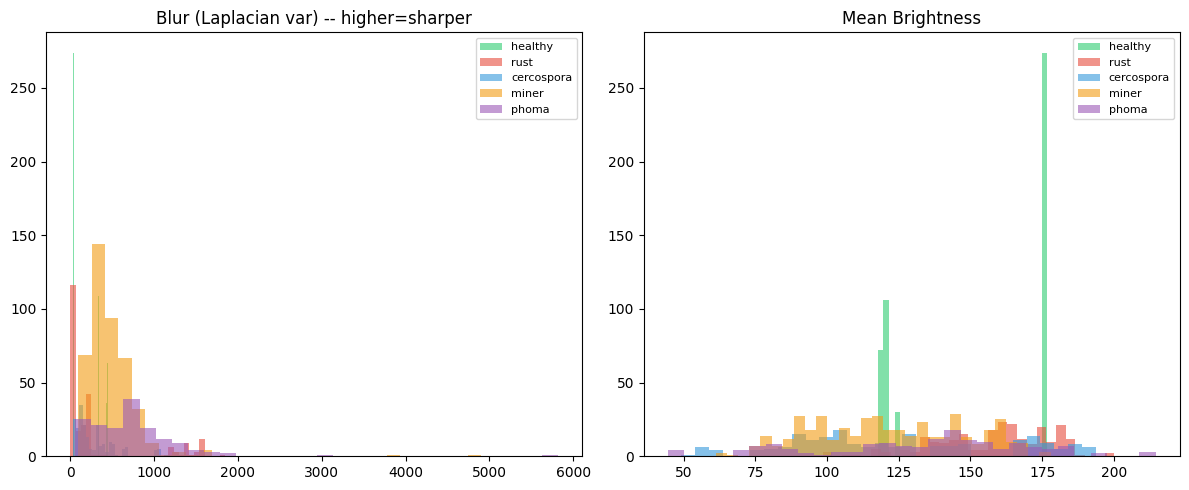

Blurry images (Laplacian<50): 390/1500 (26.0%)


In [8]:
blur_scores, brightness_scores, labels_q = [], [], []
for _, row in df.sample(min(1500,len(df)), random_state=42).iterrows():
    try:
        gray = cv2.imread(row['path'], cv2.IMREAD_GRAYSCALE)
        if gray is None: continue
        blur_scores.append(cv2.Laplacian(gray, cv2.CV_64F).var())
        brightness_scores.append(gray.mean())
        labels_q.append(row['label'])
    except: pass

qdf = pd.DataFrame({'blur':blur_scores,'brightness':brightness_scores,'label':labels_q})
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for lbl in UNIFIED_LABELS:
    sub = qdf[qdf['label']==lbl]
    if sub.empty: continue
    axes[0].hist(sub['blur'], bins=30, alpha=0.6, label=lbl, color=CLASS_COLORS[lbl])
    axes[1].hist(sub['brightness'], bins=30, alpha=0.6, label=lbl, color=CLASS_COLORS[lbl])
axes[0].set_title('Blur (Laplacian var) -- higher=sharper')
axes[0].legend(fontsize=8)
axes[1].set_title('Mean Brightness')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('../results/figures/image_quality.png', dpi=150, bbox_inches='tight')
plt.show()
blurry = (qdf['blur'] < 50).sum()
print(f'Blurry images (Laplacian<50): {blurry}/{len(qdf)} ({blurry/len(qdf)*100:.1f}%)')


## 8. Dataset Coverage Heatmap

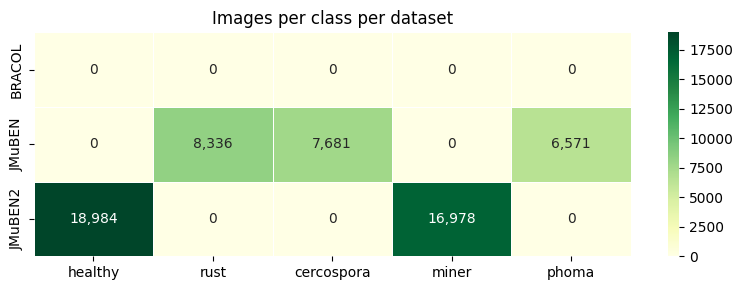

In [9]:
coverage = pd.DataFrame(0, index=list(DATASETS.keys()), columns=UNIFIED_LABELS)
for ds_name, ds_root in DATASETS.items():
    sub = df[df['dataset']==ds_root.name]
    for lbl in UNIFIED_LABELS:
        coverage.loc[ds_name, lbl] = int((sub['label']==lbl).sum())

fig, ax = plt.subplots(figsize=(8,3))
sns.heatmap(coverage.astype(int), annot=True, fmt=',d', cmap='YlGn', ax=ax, linewidths=0.5)
ax.set_title('Images per class per dataset')
plt.tight_layout()
plt.savefig('../results/figures/dataset_coverage.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Normalization Constants

In [10]:
R, G, B = [], [], []
for _, row in df.sample(min(2000,len(df)), random_state=42).iterrows():
    try:
        arr = np.array(Image.open(row['path']).convert('RGB').resize((224,224))).astype(np.float32)/255.0
        R.append(arr[:,:,0].mean()); G.append(arr[:,:,1].mean()); B.append(arr[:,:,2].mean())
    except: pass
mean = [np.mean(R), np.mean(G), np.mean(B)]
std  = [np.std(R),  np.std(G),  np.std(B)]
print(f'Dataset mean: [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]')
print(f'Dataset std:  [{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}]')
print('ImageNet:     mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]')


Dataset mean: [0.4678, 0.6106, 0.4048]
Dataset std:  [0.1598, 0.1439, 0.1563]
ImageNet:     mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


## 10. Summary & Recommendations

In [11]:
print('='*55)
print('SUMMARY')
print('='*55)
print(f'Total images: {len(df):,}')
print(f'Classes: {UNIFIED_LABELS}')
print()
for lbl in UNIFIED_LABELS:
    n = (df['label']==lbl).sum()
    print(f'  {lbl:12s}: {n:6,}')
print()
print('Recommendations:')
print('  1. Weighted CrossEntropyLoss if imbalance > 3x')
print('  2. Resize to 224x224 (EfficientNet/ViT standard)')
print('  3. Augment: flip, rotation, ColorJitter, RandomErasing')
print('  4. Stratified 70/15/15 train/val/test split')
print('  5. For QDL: also test 64x64 to reduce qubit overhead')


SUMMARY
Total images: 58,550
Classes: ['healthy', 'rust', 'cercospora', 'miner', 'phoma']

  healthy     : 18,984
  rust        :  8,336
  cercospora  :  7,681
  miner       : 16,978
  phoma       :  6,571

Recommendations:
  1. Weighted CrossEntropyLoss if imbalance > 3x
  2. Resize to 224x224 (EfficientNet/ViT standard)
  3. Augment: flip, rotation, ColorJitter, RandomErasing
  4. Stratified 70/15/15 train/val/test split
  5. For QDL: also test 64x64 to reduce qubit overhead
